# Import Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

from torchvision import datasets
from torchvision import models

from torch.utils.data import DataLoader

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from tensorflow import keras
from tensorflow.keras.datasets import fashion_mnist

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input

from tensorflow.keras.utils import to_categorical

# Restnet
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image

# Load Datasets

In [11]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

In [27]:
X_train.shape

(60000, 28, 28)

In [28]:
X_test.shape

(10000, 28, 28)

In [29]:
y_train.shape

(60000,)

In [30]:
y_test.shape

(10000,)

# Visualize Images

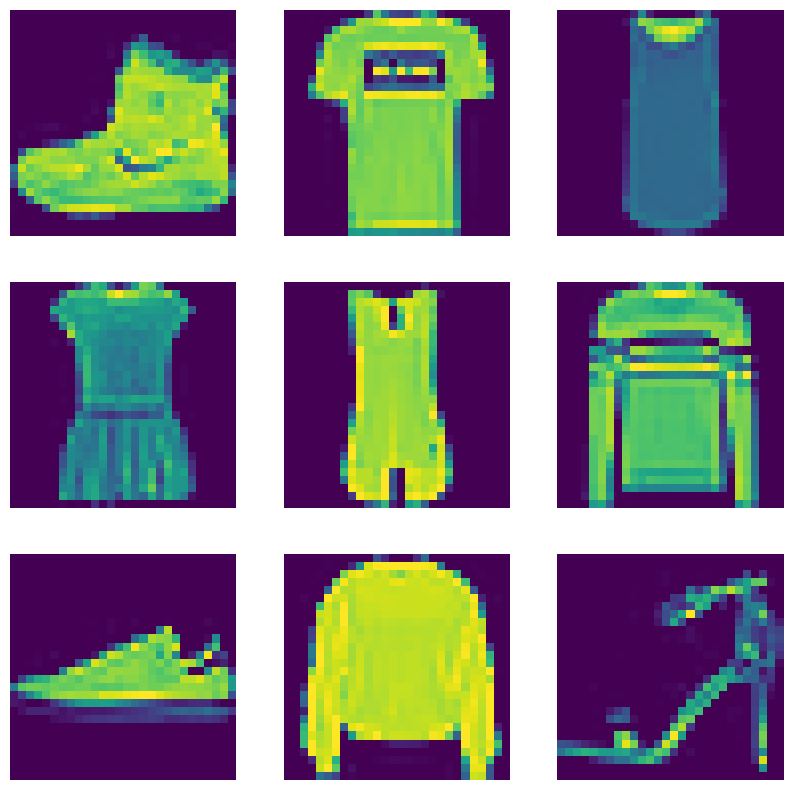

In [3]:
plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i])
    plt.axis("off")

plt.show()

# Data Preprocessing

In [12]:
# Normalize pixel values
# original: 0 to 255, convert to: 0 to 1
X_train = X_train / 255
X_test = X_test / 255

In [13]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [14]:
y_train.shape

(60000, 10)

# Baseline Model - ANN

In [17]:
model_ANN = keras.Sequential([keras.layers.Flatten(input_shape=(28,28)),
                              keras.layers.Dense(128, activation='relu'),
                              keras.layers.Dropout(0.3),
                              keras.layers.Dense(10, activation='softmax')
                            ])

In [18]:
# Compile
model_ANN.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics = ['accuracy'])

In [19]:
# Train history
history_ANN = model_ANN.fit(X_train, y_train, epochs=10, 
                            validation_data=(X_test, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8024 - loss: 0.5548 - val_accuracy: 0.8468 - val_loss: 0.4280
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8464 - loss: 0.4220 - val_accuracy: 0.8536 - val_loss: 0.4015
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8582 - loss: 0.3892 - val_accuracy: 0.8558 - val_loss: 0.3954
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8653 - loss: 0.3699 - val_accuracy: 0.8633 - val_loss: 0.3797
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8705 - loss: 0.3522 - val_accuracy: 0.8652 - val_loss: 0.3725
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8733 - loss: 0.3440 - val_accuracy: 0.8664 - val_loss: 0.3695
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8769 - loss: 0.3319 - val_accuracy: 0.8702 - val_loss: 0.3568
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8780 - loss: 0.3263 - 

# Evaluate Model

In [20]:
test_loss,test_acc = model_ANN.evaluate(
    X_test,
    y_test
)

print(test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step - accuracy: 0.8774 - loss: 0.3493
0.8773999810218811


# Train vs Test Loss

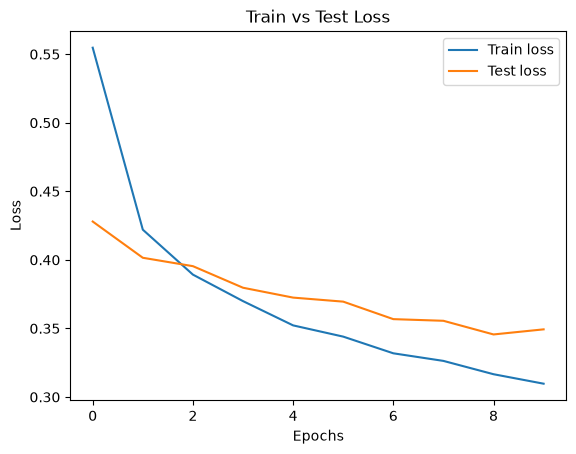

In [22]:
plt.plot(history_ANN.history['loss'], label='Train loss')
plt.plot(history_ANN.history['val_loss'], label='Test loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train vs Test Loss')
plt.legend()
plt.show()

# Train Accuracy vs Test Accuracy

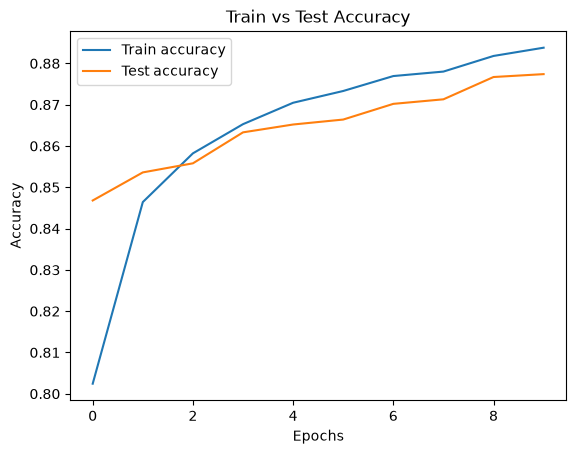

In [25]:
plt.plot(history_ANN.history['accuracy'], label='Train accuracy')
plt.plot(history_ANN.history['val_accuracy'], label='Test accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy')
plt.legend()
plt.show()

# CNN Model

In [27]:
model_CNN = keras.Sequential([
    keras.layers.Reshape((28,28,1), input_shape=(28,28)),
    keras.layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
                              ])

In [28]:
# Compile
model_CNN.compile(optimizer='Adam',
                  loss='categorical_crossentropy',
                  metrics = ['Accuracy'])

In [29]:
# Train history
history_CNN = model_CNN.fit(X_train, y_train, epochs=20, 
                            validation_data=(X_test, y_test))

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 65s 34ms/step - Accuracy: 0.8539 - loss: 0.4030 - val_Accuracy: 0.8678 - val_loss: 0.3553
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - Accuracy: 0.9041 - loss: 0.2625 - val_Accuracy: 0.8994 - val_loss: 0.2710
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - Accuracy: 0.9193 - loss: 0.2192 - val_Accuracy: 0.9085 - val_loss: 0.2532
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - Accuracy: 0.9303 - loss: 0.1865 - val_Accuracy: 0.9194 - val_loss: 0.2343
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - Accuracy: 0.9412 - loss: 0.1581 - val_Accuracy: 0.9211 - val_loss: 0.2249
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - Accuracy: 0.9493 - loss: 0.1354 - val_Accuracy: 0.9201 - val_loss: 0.2420
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - Accuracy: 0.9585 - loss: 0.1132 - val_Accuracy: 0.9185 - val_loss: 0.2557
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - Accuracy: 0.9646 - loss: 0.0

In [30]:
test_loss,test_acc = model_CNN.evaluate(
    X_test,
    y_test
)

print(test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Accuracy: 0.9193 - loss: 0.5451
0.9193000197410583


# Train vs Test Loss

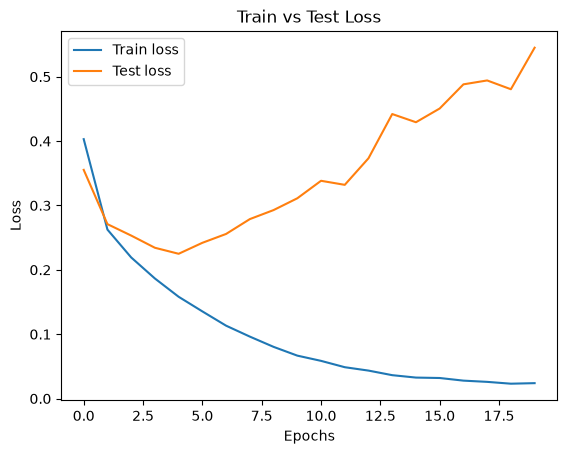

In [37]:
plt.plot(history_CNN.history['loss'], label='Train loss')
plt.plot(history_CNN.history['val_loss'], label='Test loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train vs Test Loss')
plt.legend()
plt.show()

# Train Accuracy vs Test Accuracy

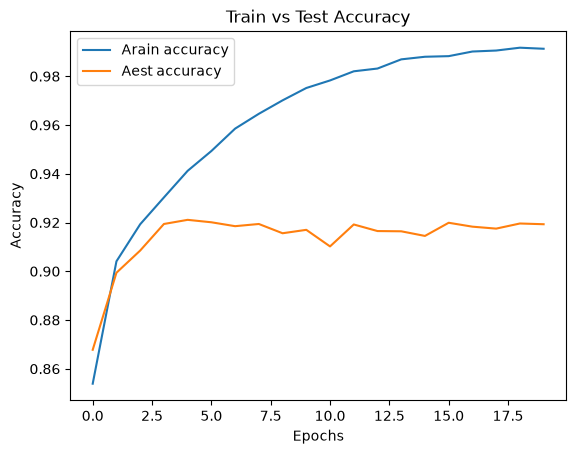

In [36]:
plt.plot(history_CNN.history['Accuracy'], label='Arain accuracy')
plt.plot(history_CNN.history['val_Accuracy'], label='Aest accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy')
plt.legend()
plt.show()

# Transfer Learning using Pre-trained Model (restNet50)

In [35]:

# Load the pre-trained ResNet-50 model

model = ResNet50(weights='imagenet')

# Load my image and resize to standard 224x224
try:
    img = image.load_img('../datasets/20260711_153204.jpg', target_size=(224, 224))
    x = image.img_to_array(img)
except FileNotFoundError:
    print("Image not found. Generating dummy sample image.")
    x = np.random.rand(224, 224, 3) * 255

# Format image for the network (add batch dim & run ResNet normalization)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

# Predict and output the top 3 highest-confidence labels
preds = model.predict(x)
print('Predicted:', decode_predictions(preds, top=3)[0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 902ms/step
Predicted: [('n07714571', 'head_cabbage', np.float32(0.9828031)), ('n03967562', 'plow', np.float32(0.014424353)), ('n07718472', 'cucumber', np.float32(0.000540654))]


# Model Comparison

| Model    | Accuracy |
| -------- | -------- |
| ANN      | 88%      |
| CNN      | 99%      |
